In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"titanic(dataset).csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [6]:
df.isnull().sum()   ## sum of total nan present in co;lumns

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [7]:
df.isnull().sum()/df.shape[0]*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64

In [8]:
df.isnull().mean()*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64

### more than 97% NAN value belongs to age and cabin

In [11]:
df[df['Fare'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,0,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


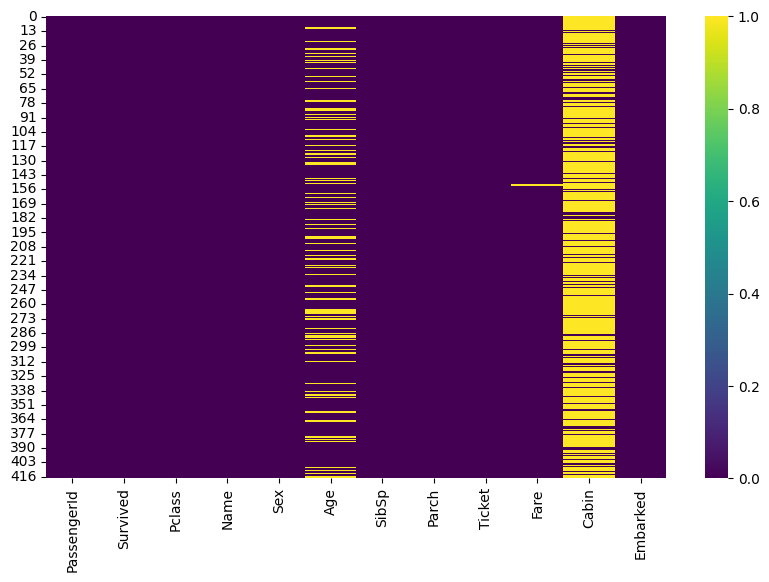

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cmap='viridis')
plt.show()

In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,418.0,1100.500000,120.810458,892.00,996.2500,1100.5000,1204.75,1309.0000
Survived,418.0,0.363636,0.481622,0.00,0.0000,0.0000,1.00,1.0000
Pclass,418.0,2.265550,0.841838,1.00,1.0000,3.0000,3.00,3.0000
Age,332.0,30.272590,14.181209,0.17,21.0000,27.0000,39.00,76.0000
SibSp,418.0,0.447368,0.896760,0.00,0.0000,0.0000,1.00,8.0000
Parch,418.0,0.392344,0.981429,0.00,0.0000,0.0000,0.00,9.0000
Fare,417.0,35.627188,55.907576,0.00,7.8958,14.4542,31.50,512.3292


In [34]:
df.describe(include='O').T

,count,unique,top,freq
Name,418,418,"Kelly, Mr. James",1
Sex,418,2,male,266
Ticket,418,363,PC 17608,5
Cabin,91,76,B57 B59 B63 B66,3
Embarked,418,3,S,270


In [35]:
object_col=df.select_dtypes(include='object').columns
object_col

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [36]:
for col in object_col:
    print('__'*16)
    print(df[col].value_counts(dropna=False))
    print('__'*16)

________________________________
Kelly, Mr. James               1
Carr, Miss. Jeannie            1
Dennis, Mr. William            1
Rosblom, Miss. Salli Helena    1
Touma, Miss. Maria Youssef     1
                              ..
Zakarian, Mr. Mapriededer      1
Carlsson, Mr. Carl Robert      1
Dintcheff, Mr. Valtcho         1
Thomas, Mr. Charles P          1
Peter, Master. Michael J       1
Name: Name, Length: 418, dtype: int64
________________________________
________________________________
male      266
female    152
Name: Sex, dtype: int64
________________________________
________________________________
PC 17608    5
CA. 2343    4
113503      4
PC 17483    3
220845      3
           ..
349226      1
2621        1
4133        1
113780      1
2668        1
Name: Ticket, Length: 363, dtype: int64
________________________________
________________________________
NaN                327
B57 B59 B63 B66      3
C89                  2
C116                 2
C80                  2
       

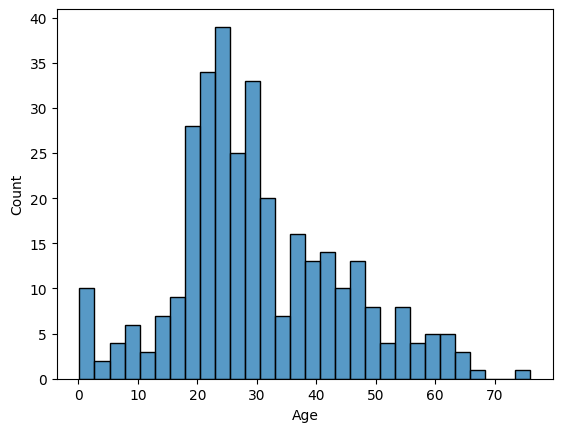

In [37]:
sns.histplot(data=df,x=df['Age'],kde=False,bins=30);

In [38]:
df.Age.mean()

30.272590361445783

In [39]:
df.Age.median()

27.0

<Axes: ylabel='Age'>

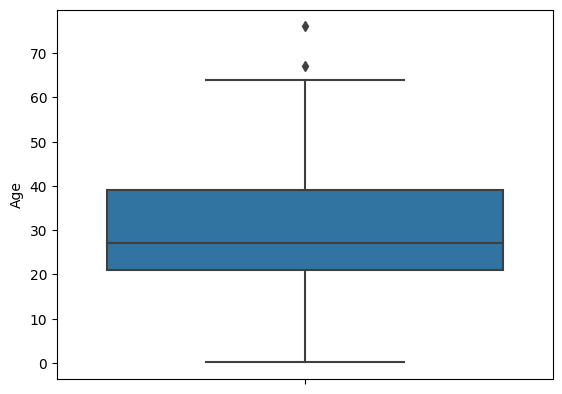

In [40]:
sns.boxplot(data=df,y='Age')

In [41]:
df.groupby('Pclass').Age.median()

Pclass
1    42.0
2    26.5
3    24.0
Name: Age, dtype: float64

In [42]:
df.groupby('Pclass').Age.median()

Pclass
1    42.0
2    26.5
3    24.0
Name: Age, dtype: float64

<Axes: xlabel='Pclass', ylabel='Age'>

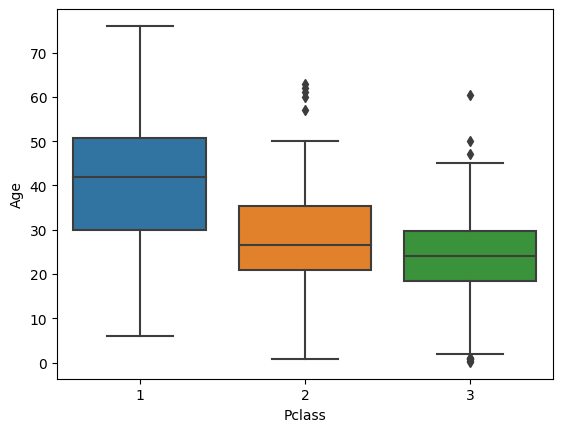

In [43]:
sns.boxplot(data=df,x='Pclass',y='Age')

In [44]:
df.groupby(['Pclass','Sex']).Age.median()

Pclass  Sex   
1       female    41.0
        male      42.0
2       female    24.0
        male      28.0
3       female    22.0
        male      24.0
Name: Age, dtype: float64

<Axes: xlabel='Pclass', ylabel='Age'>

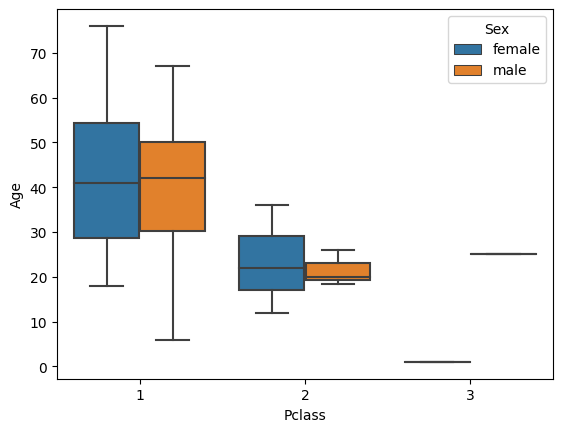

In [55]:
sns.boxplot(data=df,x='Pclass',y='Age',hue='Sex')

In [46]:
df.groupby(['Pclass','Sex']).Age.transform('median')

0      24.0
1      22.0
2      28.0
3      24.0
4      22.0
       ... 
413    24.0
414    41.0
415    24.0
416    24.0
417    24.0
Name: Age, Length: 418, dtype: float64

In [47]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [48]:
# first 5 
head=df.head()
head

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [49]:
#df.drop('Cabin',axis=1,inplace=True)


In [50]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

# Embarked

In [51]:
df.dropna(inplace=True)

In [52]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

# Survive

In [60]:
df.Survived.value_counts(normalize=True)

1    0.505747
0    0.494253
Name: Survived, dtype: float64

<Axes: xlabel='Survived', ylabel='count'>

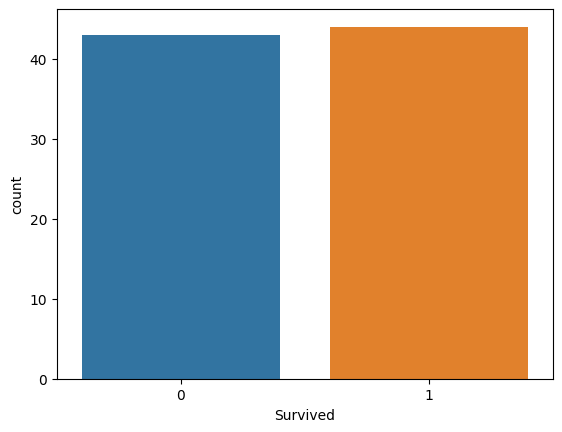

In [57]:
sns.countplot(data=df,x='Survived')

# gender

In [58]:
df.groupby('Sex').Survived.value_counts()

Sex     Survived
female  1           44
male    0           43
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='count'>

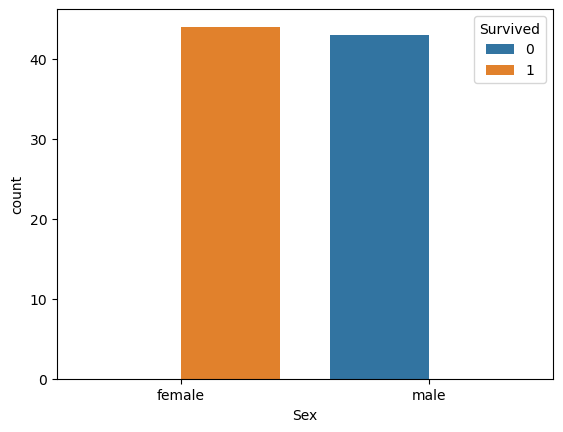

In [32]:
sns.countplot(data=df,x='Sex',hue='Survived')

In [33]:
df.groupby('Sex').Survived.value_counts(normalize=True)

Sex     Survived
female  1           1.0
male    0           1.0
Name: Survived, dtype: float64

# Pclass

<Axes: xlabel='Pclass', ylabel='count'>

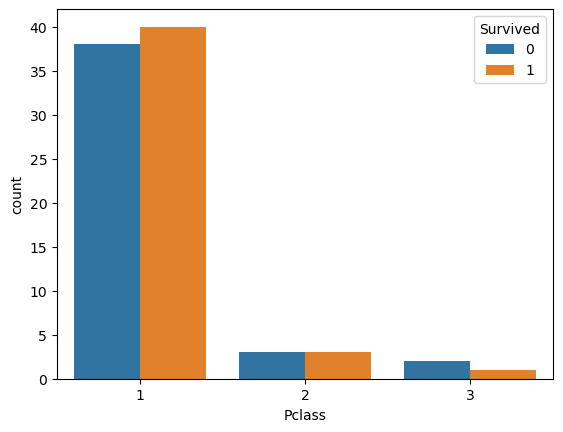

In [34]:
sns.countplot(data=df,x='Pclass',hue='Survived')

# sibbp

<Axes: xlabel='SibSp', ylabel='count'>

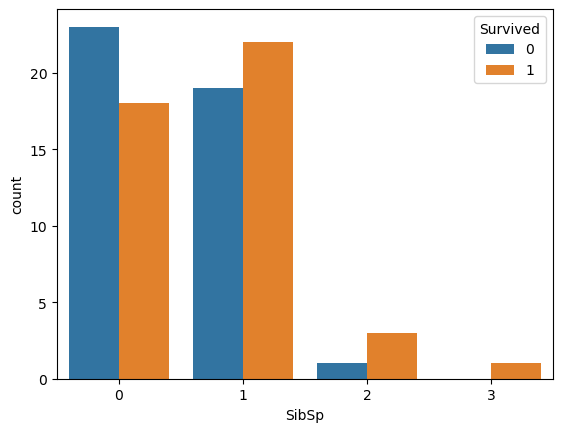

In [35]:
sns.countplot(data=df,x='SibSp',hue='Survived')

# Parch

<Axes: xlabel='Parch', ylabel='count'>

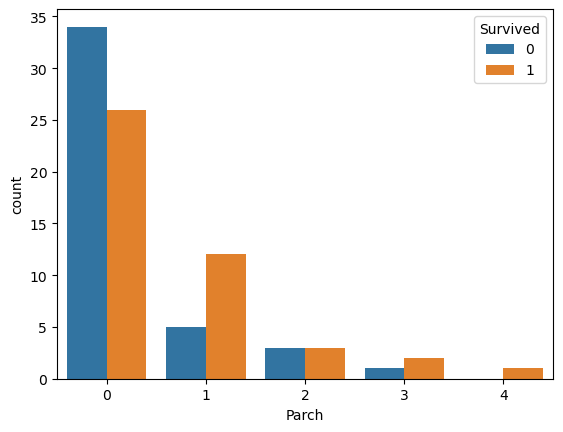

In [36]:
sns.countplot(data=df,x='Parch',hue='Survived')

# Embarked

<Axes: xlabel='Embarked', ylabel='count'>

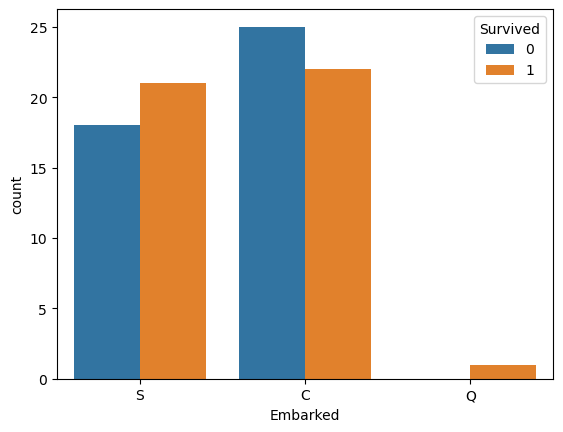

In [37]:
sns.countplot(data= df,x = 'Embarked',hue='Survived')

# age

In [38]:
df.groupby('Survived').Age.median()

Survived
0    41.0
1    36.5
Name: Age, dtype: float64

In [39]:
df.groupby('Survived').Age.mean()

Survived
0    38.895349
1    39.590909
Name: Age, dtype: float64

<Axes: xlabel='Survived', ylabel='Age'>

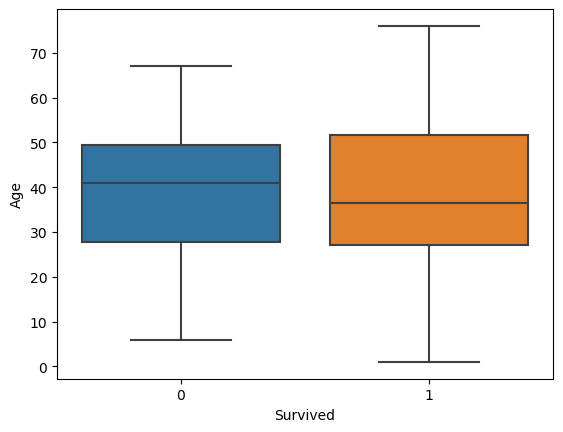

In [40]:
sns.boxplot(data=df,x='Survived',y='Age')

<Axes: xlabel='Age', ylabel='Density'>

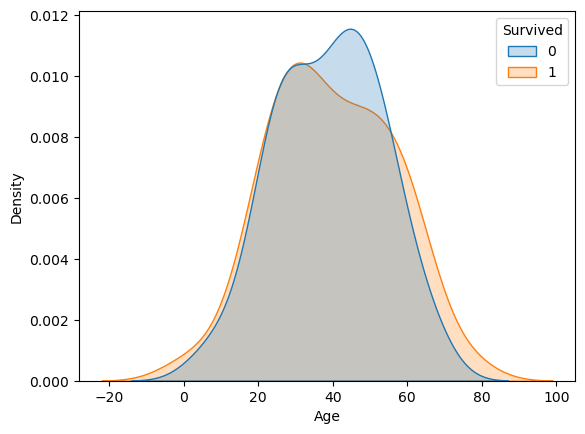

In [42]:
sns.kdeplot(data=df,x='Age',hue='Survived',fill=True)

# fare

In [77]:
df.groupby('Survived').Fare.median()

Survived
0    57.750
1    79.025
Name: Fare, dtype: float64

<Axes: xlabel='Survived', ylabel='Fare'>

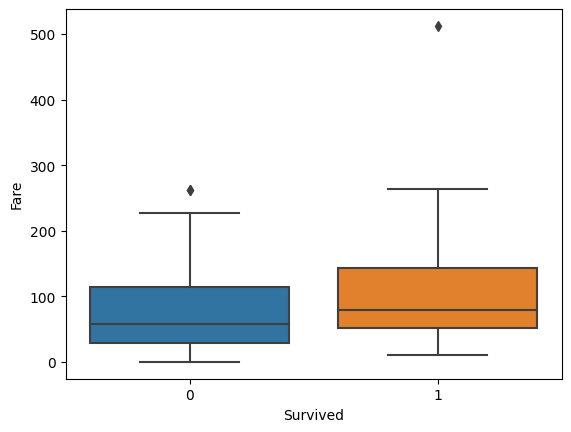

In [78]:
sns.boxplot(data=df,x='Survived',y='Fare')

<Axes: xlabel='Fare', ylabel='Density'>

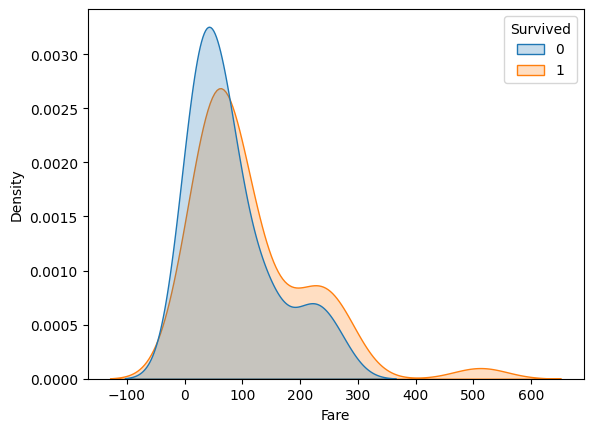

In [79]:
sns.kdeplot(data=df,x='Fare',hue='Survived',fill=True)

# Ticket

In [80]:
ticket=df.Ticket.value_counts(dropna=False)
ticket

113503         4
PC 17608       4
16966          3
PC 17483       3
21228          2
              ..
W.E.P. 5734    1
PC 17613       1
113038         1
W./C. 14266    1
PC 17758       1
Name: Ticket, Length: 66, dtype: int64

In [81]:
ticket[ticket!=1]

113503      4
PC 17608    4
16966       3
PC 17483    3
21228       2
13508       2
33638       2
12749       2
PC 17756    2
230136      2
13050       2
11778       2
19950       2
13236       2
13695       2
Name: Ticket, dtype: int64

In [82]:
group_list=list(ticket[ticket!=1].index)
group_list

['113503',
 'PC 17608',
 '16966',
 'PC 17483',
 '21228',
 '13508',
 '33638',
 '12749',
 'PC 17756',
 '230136',
 '13050',
 '11778',
 '19950',
 '13236',
 '13695']

In [83]:
df['is_group']=df.Ticket.isin(group_list)*1
df['is_group']

12     1
14     0
24     1
26     0
28     0
      ..
404    0
405    0
407    1
411    0
414    0
Name: is_group, Length: 87, dtype: int32

<Axes: xlabel='is_group', ylabel='count'>

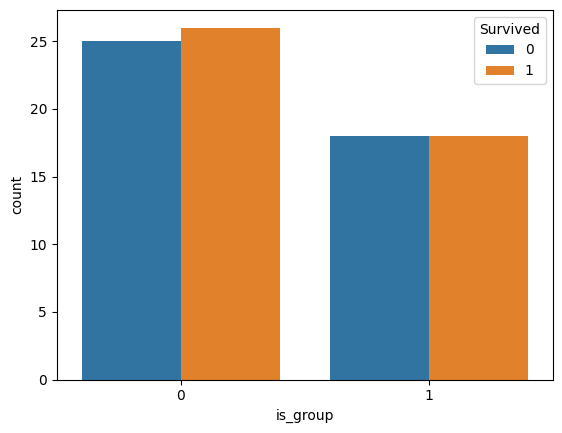

In [84]:
sns.countplot(data=df,x='is_group',hue='Survived')

# SibSp and Parch

In [85]:
df.SibSp

12     1
14     1
24     1
26     0
28     0
      ..
404    1
405    0
407    1
411    1
414    0
Name: SibSp, Length: 87, dtype: int64

In [86]:
df.Parch

12     0
14     0
24     3
26     1
28     0
      ..
404    0
405    0
407    1
411    0
414    0
Name: Parch, Length: 87, dtype: int64

In [87]:
df['is_alone']=((df.SibSp==0) & (df.Parch==0))*1
df.is_alone

12     0
14     0
24     0
26     0
28     1
      ..
404    0
405    1
407    0
411    0
414    1
Name: is_alone, Length: 87, dtype: int32

<Axes: xlabel='is_alone', ylabel='count'>

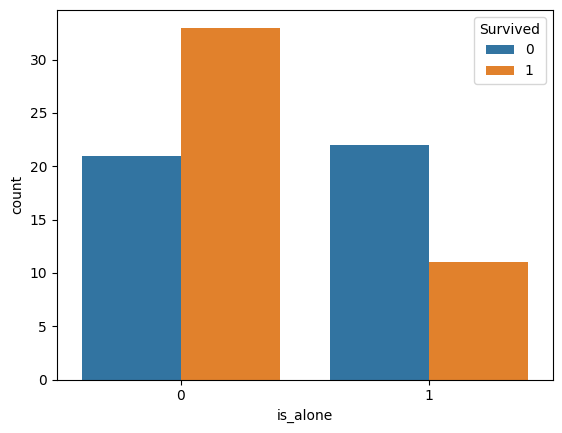

In [88]:
sns.countplot(data=df,x='is_alone',hue='Survived')

# is_alone & is_group

In [89]:
df.groupby('is_group').is_alone.value_counts()


is_group  is_alone
0         0           26
          1           25
1         0           28
          1            8
Name: is_alone, dtype: int64

In [90]:
df.Name

12         Snyder, Mrs. John Pillsbury (Nelle Stevenson)
14     Chaffee, Mrs. Herbert Fuller (Carrie Constance...
24       Ryerson, Mrs. Arthur Larned (Emily Maria Borie)
26                          Ostby, Miss. Helene Ragnhild
28                               Brady, Mr. John Bertram
                             ...                        
404                         Frauenthal, Mr. Isaac Gerald
405         Nourney, Mr. Alfred (Baron von Drachstedt")"
407                           Widener, Mr. George Dunton
411      Minahan, Mrs. William Edward (Lillian E Thorpe)
414                         Oliva y Ocana, Dona. Fermina
Name: Name, Length: 87, dtype: object

In [91]:
df.Name.sample(10)

236                             Warren, Mr. Frank Manley
350         Greenfield, Mrs. Leo David (Blanche Strouse)
331                         Dulles, Mr. William Crothers
44      Kimball, Mrs. Edwin Nelson Jr (Gertrude Parsons)
196                      Spedden, Master. Robert Douglas
59                           Chaudanson, Miss. Victorine
326                         Becker, Miss. Ruth Elizabeth
96     Cavendish, Mrs. Tyrell William (Julia Florence...
28                               Brady, Mr. John Bertram
218         Widener, Mrs. George Dunton (Eleanor Elkins)
Name: Name, dtype: object

In [92]:
df.Name.str.split(',').str[1].str.split("(").str[0].str.split('"').str[0].str.split('.').str[1].str.strip()

12      John Pillsbury
14      Herbert Fuller
24       Arthur Larned
26     Helene Ragnhild
28        John Bertram
            ...       
404       Isaac Gerald
405             Alfred
407      George Dunton
411     William Edward
414            Fermina
Name: Name, Length: 87, dtype: object

In [93]:
df.Name.str.extract('\w+\.\s(\w*\s*\w*)')

,0
12,John Pillsbury
14,Herbert Fuller
24,Arthur Larned
26,Helene Ragnhild
28,John Bertram
...,...
404,Isaac Gerald
405,Alfred
407,George Dunton
411,William Edward


In [94]:
df['Name'] =  df.Name.str.extract("\w+\.\s(\w*\s*\w*)" )
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,is_group,is_alone
12,904,1,1,John Pillsbury,female,23.0,1,0,21228,82.2667,B45,S,1,0
14,906,1,1,Herbert Fuller,female,47.0,1,0,W.E.P. 5734,61.1750,E31,S,0,0
24,916,1,1,Arthur Larned,female,48.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C,1,0
26,918,1,1,Helene Ragnhild,female,22.0,0,1,113509,61.9792,B36,C,0,0
28,920,0,1,John Bertram,male,41.0,0,0,113054,30.5000,A21,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,1296,0,1,Isaac Gerald,male,43.0,1,0,17765,27.7208,D40,C,0,0
405,1297,0,2,Alfred,male,20.0,0,0,SC/PARIS 2166,13.8625,D38,C,0,1
407,1299,0,1,George Dunton,male,50.0,1,1,113503,211.5000,C80,C,1,0
411,1303,1,1,William Edward,female,37.0,1,0,19928,90.0000,C78,Q,0,0


# Ticket

In [95]:
df['ticket']=df.Ticket.str.extract('(\d*)$')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,is_group,is_alone,ticket
12,904,1,1,John Pillsbury,female,23.0,1,0,21228,82.2667,B45,S,1,0,21228
14,906,1,1,Herbert Fuller,female,47.0,1,0,W.E.P. 5734,61.1750,E31,S,0,0,5734
24,916,1,1,Arthur Larned,female,48.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C,1,0,17608
26,918,1,1,Helene Ragnhild,female,22.0,0,1,113509,61.9792,B36,C,0,0,113509
28,920,0,1,John Bertram,male,41.0,0,0,113054,30.5000,A21,S,0,1,113054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,1296,0,1,Isaac Gerald,male,43.0,1,0,17765,27.7208,D40,C,0,0,17765
405,1297,0,2,Alfred,male,20.0,0,0,SC/PARIS 2166,13.8625,D38,C,0,1,2166
407,1299,0,1,George Dunton,male,50.0,1,1,113503,211.5000,C80,C,1,0,113503
411,1303,1,1,William Edward,female,37.0,1,0,19928,90.0000,C78,Q,0,0,19928


# Droping unnecessary features

In [96]:
df_final=df.drop(['PassengerId','Name',"ticket"],axis=1)
df_final

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,is_group,is_alone
12,1,1,female,23.0,1,0,21228,82.2667,B45,S,1,0
14,1,1,female,47.0,1,0,W.E.P. 5734,61.1750,E31,S,0,0
24,1,1,female,48.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C,1,0
26,1,1,female,22.0,0,1,113509,61.9792,B36,C,0,0
28,0,1,male,41.0,0,0,113054,30.5000,A21,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
404,0,1,male,43.0,1,0,17765,27.7208,D40,C,0,0
405,0,2,male,20.0,0,0,SC/PARIS 2166,13.8625,D38,C,0,1
407,0,1,male,50.0,1,1,113503,211.5000,C80,C,1,0
411,1,1,female,37.0,1,0,19928,90.0000,C78,Q,0,0


C:\Users\hp\AppData\Local\Temp\ipykernel_24348\4140759874.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_final.corr(),annot=True)


<Axes: >

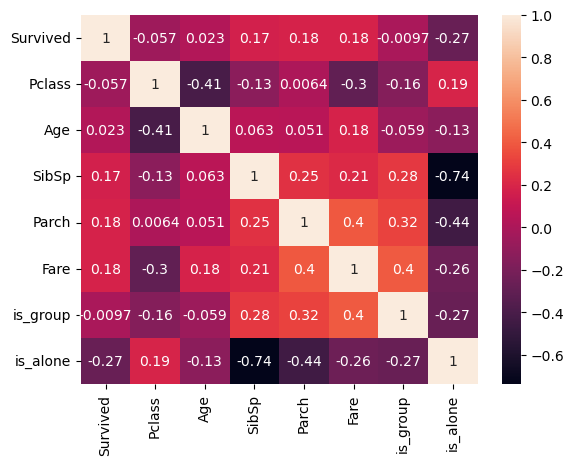

In [72]:
sns.heatmap(df_final.corr(),annot=True)

## by using profileing make a overview file which help us visulaizing

In [3]:
from ydata_profiling import ProfileReport

In [4]:
profile = ProfileReport(df,title="overview_titanic")

In [5]:
profile.to_file("overview_titanic")

C:\Users\hp\anaconda3\lib\site-packages\ydata_profiling\profile_report.py:363: UserWarning: Try running command: 'pip install --upgrade Pillow' to avoid ValueError
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\hp\anaconda3\lib\site-packages\ydata_profiling\profile_report.py:384: UserWarning: Extension  not supported. For now we assume .html was intended. To remove this warning, please use .html or .json.
  warnings.warn(


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]